### 자연어 처리 : 텍스트 요약 개발 파이프라인

이 노트북은 **`텍스트 요약` 개발 파이프라인 예제 실습**을 수행하는 노트북입니다.

##### KLUE-BERT를 활용한 문서 분류 개발 파이프라인 예제
   1.  한국어 텍스트 요약 모델 Fine-Tuning 및 저장 (Cell 11개)
   2.  Fine-Tuning 한 텍스트 요약 모델 성능 평가 (Cell 7개)

### 01. 한국어 텍스트 요약 모델 Fine-Tuning 및 저장

사전 학습된 한국어 요약 모델(`gangyeolkim/kobart-korean-summarizer-v2`)을 

XL-Sum(BBC에서 제공하는 다국어 뉴스 요약) Korean 데이터셋으로 Fine-Tuning합니다.

LoRA 기법을 활용하여 효율적으로 모델을 특화시키고, 학습 과정을 시각화하여 성능 변화를 모니터링합니다.

* XL-Sum Korean 데이터셋 로드 및 한국어 텍스트 전처리 (HTML 태그 제거, 길이 정규화 등)
* BART 기반 한국어 요약 모델 로드 및 LoRA 설정으로 효율적인 Fine-tuning 환경 구성
* 학습 파라미터 설정 및 데이터 콜레이터를 통한 배치 처리 준비
* Trainer를 사용한 Fine-tuning 실행 및 최종 모델 저장
* 학습 과정의 loss 변화를 그래프로 시각화하여 성능 모니터링

In [2]:
# ============================================
# Cell 1: 환경 설정 및 라이브러리 임포트
# ============================================

# 환경 설정
import os
import torch
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm  # 진행률 표시를 위한 라이브러리
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # 불필요한 경고 메시지 숨김

# Transformers 경고 메시지 레벨 설정
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

# 한글 폰트 설정 - 그래프에서 한글이 깨지지 않도록 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows용 한글 폰트
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 필요한 라이브러리 import
from datasets import load_dataset  # Hugging Face 데이터셋 로드
from transformers import (
    PreTrainedTokenizerFast,  # 토크나이저
    BartForConditionalGeneration,  # BART 모델
    TrainingArguments,  # 학습 설정
    Trainer,  # 학습 관리자
    DataCollatorForSeq2Seq  # 시퀀스-투-시퀀스 데이터 처리
)
from peft import LoraConfig, get_peft_model, TaskType  # LoRA 설정
from kiwipiepy import Kiwi  # 한국어 형태소 분석기
import re  # 정규표현식

print("라이브러리 임포트 완료!")


라이브러리 임포트 완료!


In [3]:
# ============================================
# Cell 2: GPU 설정 및 확인
# ============================================
# CUDA가 사용 가능한 경우 GPU를 사용하고, 그렇지 않으면 CPU 사용
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Device: {device}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")  # GPU 모델명 출력
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")  # GPU 메모리 용량
else:
    device = torch.device('cpu')
    print(f"Device: {device}")

Device: cuda
GPU: NVIDIA GeForce RTX 5090
Memory: 31.84 GB


In [4]:
# ============================================
# Cell 3: 데이터셋 로드
# ============================================
print("\n" + "="*50)
print("1. 데이터셋 로드")
print("="*50)

# XL-Sum Korean 데이터셋 로드
# XL-Sum은 BBC에서 제공하는 다국어 뉴스 요약 데이터셋
dataset = load_dataset("csebuetnlp/xlsum", "korean")
print(f"학습 데이터: {len(dataset['train'])}개")
print(f"검증 데이터: {len(dataset['validation'])}개")
print(f"테스트 데이터: {len(dataset['test'])}개")

# 데이터 샘플 확인
print("\n=== 데이터 샘플 ===")
sample = dataset['train'][0]
print(f"원문 (처음 200자): {sample['text'][:200]}...")
print(f"요약문: {sample['summary']}")


1. 데이터셋 로드
학습 데이터: 4407개
검증 데이터: 550개
테스트 데이터: 550개

=== 데이터 샘플 ===
원문 (처음 200자): 1960년대 번식 프로그램이 시작되면서 가까운 에스파뇰라 섬에서 산타크루스 섬으로 거북이를 데려와 번식하게 했다. 디에고는 프로그램에 포함된 14마리 수컷 거북이 중 하나. 그는 번식 프로그램에서 맹활약한 뒤 고향으로 돌아갈 예정이다. 디에고의 활약을 영상으로 정리했다. 기사 더 보기:...
요약문: 갈라파고스에 있는 산타크루스 섬에 거북이는 멸종 위기였다.


In [5]:
# ============================================
# Cell 4: 한국어 텍스트 전처리 클래스 정의
# ============================================

# 전처리 클래스 정의
class KoreanTextPreprocessor:
    """
    한국어 텍스트 전처리를 위한 클래스
    - HTML 태그, URL, 이메일 제거
    - 특수문자 정리
    - 텍스트 길이 정규화
    """
    
    def __init__(self):
        # Kiwi 형태소 분석기 초기화
        self.kiwi = Kiwi()
        
    def clean_text(self, text):
        """
        텍스트 정제 함수
        불필요한 요소들을 제거하고 깔끔한 텍스트로 만듦
        """
        # HTML 태그 제거 (예: <p>, <div> 등)
        text = re.sub(r'<[^>]+>', '', text)
        
        # URL 제거 (http://, https://, www. 로 시작하는 주소)
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        
        # 이메일 주소 제거
        text = re.sub(r'\S+@\S+', '', text)
        
        # 특수문자 제거 (한글, 영문, 숫자, 기본 문장부호만 유지)
        text = re.sub(r'[^가-힣a-zA-Z0-9\s\.\,\!\?\-\(\)]', ' ', text)
        
        # 연속된 공백을 하나의 공백으로 변환
        text = re.sub(r'\s+', ' ', text)
        
        # 문장 부호 주변의 공백 정리
        text = re.sub(r'\s*([.!?])\s*', r'\1 ', text)
        
        return text.strip()
    
    def normalize_length(self, text, max_length=1024):
        """
        텍스트 길이를 정규화하는 함수
        너무 긴 텍스트는 문장 단위로 잘라서 max_length 이내로 조정
        """
        # 텍스트를 토큰으로 분리
        tokens = self.kiwi.tokenize(text)
        
        # 토큰 수가 최대 길이를 초과하는 경우
        if len(tokens) > max_length:
            # 문장 단위로 분리
            sentences = text.split('.')
            truncated = []
            current_length = 0
            
            # 각 문장을 추가하면서 길이 체크
            for sent in sentences:
                sent_tokens = self.kiwi.tokenize(sent)
                # 현재 길이 + 새 문장 길이가 최대 길이를 초과하면 중단
                if current_length + len(sent_tokens) > max_length:
                    break
                truncated.append(sent)
                current_length += len(sent_tokens)
            
            # 문장들을 다시 합치고 마침표 추가
            return '.'.join(truncated) + '.'
        return text
    
    def preprocess_for_summarization(self, text):
        """
        요약을 위한 전체 전처리 파이프라인
        1. 텍스트 정제
        2. 길이 정규화
        """
        text = self.clean_text(text)
        text = self.normalize_length(text)
        return text

# 전처리기 초기화
preprocessor = KoreanTextPreprocessor()
print("전처리 클래스 정의 완료!")

전처리 클래스 정의 완료!


In [6]:
# ============================================
# Cell 5: 토크나이저 로드 및 전처리 함수 정의
# ============================================

print("\n" + "="*50)
print("2. 데이터셋 전처리")
print("="*50)

# 토크나이저 로드
# gangyeolkim/kobart-korean-summarizer-v2: 한국어 요약에 특화된 사전학습 모델
model_name = "gangyeolkim/kobart-korean-summarizer-v2"
tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name)

def preprocess_function(examples):
    """
    배치 단위로 데이터를 전처리하는 함수
    - 원문 텍스트 전처리 및 토크나이징
    - 요약문 토크나이징
    - 레이블 생성
    """
    # 각 텍스트에 대해 전처리 수행
    inputs = [preprocessor.preprocess_for_summarization(text) 
              for text in examples['text']]
    
    # 원문 텍스트 토크나이징
    model_inputs = tokenizer(
        inputs,
        max_length=1024,  # 최대 입력 길이
        truncation=True,  # 긴 텍스트는 자르기
        padding=False  # 패딩은 나중에 배치 단위로 수행
    )
    
    # BART 모델은 token_type_ids를 사용하지 않으므로 제거
    if "token_type_ids" in model_inputs:
        del model_inputs["token_type_ids"]
    
    # 타겟 요약문 토크나이징
    # as_target_tokenizer()를 사용하여 디코더 입력으로 처리
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            examples['summary'],
            max_length=128,  # 요약문 최대 길이
            truncation=True,
            padding=False
        )
    
    # 레이블 추가
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print("토크나이저 로드 및 전처리 함수 정의 완료!")


2. 데이터셋 전처리
토크나이저 로드 및 전처리 함수 정의 완료!


In [7]:
# ============================================
# Cell 6: 데이터셋 전처리 실행
# ============================================

# 소규모 샘플로 시작 (전체 데이터는 시간이 오래 걸림)
# 실제 사용 시에는 더 많은 데이터를 사용하는 것이 좋음
small_dataset = {
    'train': dataset['train'].select(range(1000)),  # 학습용 1000개
    'validation': dataset['validation'].select(range(100)),  # 검증용 100개
    'test': dataset['test'].select(range(100))  # 테스트용 100개
}

# 각 분할에 대해 전처리 수행
tokenized_dataset = {}
for split in ['train', 'validation', 'test']:
    print(f"{split} 데이터 처리 중...")
    tokenized_dataset[split] = small_dataset[split].map(
        preprocess_function,
        batched=True,  # 배치 단위로 처리
        remove_columns=dataset['train'].column_names,  # 원본 컬럼 제거
        desc=f"Processing {split}"  # 진행률 표시 설명
    )

print("데이터셋 전처리 완료!")

Parameter 'function'=<function preprocess_function at 0x0000025E39099CF0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


train 데이터 처리 중...


Processing train:   0%|          | 0/1000 [00:00<?, ? examples/s]

validation 데이터 처리 중...


Processing validation:   0%|          | 0/100 [00:00<?, ? examples/s]

test 데이터 처리 중...


Processing test:   0%|          | 0/100 [00:00<?, ? examples/s]

데이터셋 전처리 완료!


In [8]:
# ============================================
# Cell 7: 모델 로드 및 LoRA 설정
# ============================================

print("\n" + "="*50)
print("3. 모델 로드 및 LoRA 설정")
print("="*50)

# 사전학습된 BART 모델 로드
model = BartForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,  # GPU면 FP16, CPU면 FP32
    device_map=None  # 수동으로 device 설정
)
# 모델을 지정된 디바이스로 이동
model = model.to(device)

# LoRA (Low-Rank Adaptation) 설정
# LoRA는 큰 모델을 효율적으로 fine-tuning하는 기법
lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,  # 시퀀스-투-시퀀스 언어 모델 태스크
    r=8,  # LoRA rank (낮을수록 파라미터 수 감소)
    lora_alpha=32,  # LoRA scaling parameter
    lora_dropout=0.1,  # 드롭아웃 비율
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],  # LoRA를 적용할 모듈
    inference_mode=False  # 학습 모드
)

# LoRA를 모델에 적용
model = get_peft_model(model, lora_config)
model.train()  # 학습 모드로 설정

# gradient 계산을 위한 설정
if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()
    
# 학습 가능한 파라미터 정보 출력
model.print_trainable_parameters()


3. 모델 로드 및 LoRA 설정


You passed along `num_labels=3` with an incompatible id to label map: {'0': 'NEGATIVE', '1': 'POSITIVE'}. The number of labels will be overwritten to 2.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


trainable params: 663,552 || all params: 124,523,520 || trainable%: 0.5329


In [9]:
# ============================================
# Cell 8: 학습 설정 및 Data Collator 정의
# ============================================

print("\n" + "="*50)
print("4. Fine-tuning 시작")
print("="*50)

# 학습 설정 정의
training_args = TrainingArguments(
    output_dir="./kobart-summarization-finetuned",  # 모델 저장 경로
    num_train_epochs=3,  # 전체 데이터를 몇 번 반복할지
    per_device_train_batch_size=2,  # GPU/CPU당 학습 배치 크기
    per_device_eval_batch_size=2,  # GPU/CPU당 평가 배치 크기
    gradient_accumulation_steps=8,  # 그래디언트 누적 스텝 (실제 배치 크기 = 2 * 8 = 16)
    warmup_ratio=0.1,  # 학습률 웜업 비율 (전체 스텝의 10%)
    weight_decay=0.01,  # 가중치 감쇠 (정규화)
    learning_rate=3e-4,  # 학습률
    fp16=False,  # 16비트 부동소수점 사용 여부
    logging_dir='./logs',  # 로그 저장 디렉토리
    logging_steps=50,  # 로깅 주기
    eval_strategy="steps",  # 평가 전략 (스텝 단위)
    eval_steps=100,  # 평가 주기
    save_strategy="steps",  # 저장 전략 (스텝 단위)
    save_steps=200,  # 모델 저장 주기
    save_total_limit=2,  # 최대 저장 체크포인트 수
    load_best_model_at_end=True,  # 학습 종료 시 최고 성능 모델 로드
    metric_for_best_model="eval_loss",  # 최고 모델 선택 기준
    greater_is_better=False,  # eval_loss는 낮을수록 좋음
    report_to="none",  # 실험 추적 도구 사용 안함
    remove_unused_columns=False,  # 사용하지 않는 컬럼 제거 안함
    label_smoothing_factor=0.0,  # 레이블 스무싱 사용 안함
)

# 커스텀 Data Collator 정의
# token_type_ids를 제거하기 위한 커스텀 클래스
class CustomDataCollatorForSeq2Seq(DataCollatorForSeq2Seq):
    def __call__(self, features, return_tensors=None):
        # 부모 클래스의 __call__ 메서드 호출
        batch = super().__call__(features, return_tensors)
        # BART는 token_type_ids를 사용하지 않으므로 제거
        if "token_type_ids" in batch:
            del batch["token_type_ids"]
        return batch

# Data Collator 초기화
# 배치 내의 시퀀스들을 동일한 길이로 패딩
data_collator = CustomDataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,  # 동적 패딩 사용
    pad_to_multiple_of=8  # 8의 배수로 패딩 (효율성 향상)
)

print("학습 설정 및 Data Collator 정의 완료!")


4. Fine-tuning 시작
학습 설정 및 Data Collator 정의 완료!


In [10]:
# ============================================
# Cell 9: Trainer 초기화 및 학습 실행
# ============================================

# Trainer 초기화
# Hugging Face의 Trainer 클래스를 사용하여 학습 관리
trainer = Trainer(
    model=model,  # 학습할 모델
    args=training_args,  # 학습 설정
    train_dataset=tokenized_dataset['train'],  # 학습 데이터셋
    eval_dataset=tokenized_dataset['validation'],  # 검증 데이터셋
    tokenizer=tokenizer,  # 토크나이저
    data_collator=data_collator,  # 데이터 콜레이터
    compute_metrics=None,  # 평가 메트릭 (현재는 loss만 사용)
)

# 학습 시작
print("\nFine-tuning을 시작합니다...")
trainer.train()

No label_names provided for model class `PeftModelForSeq2SeqLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.



Fine-tuning을 시작합니다...


Step,Training Loss,Validation Loss
100,3.149700,2.470703


You passed along `num_labels=3` with an incompatible id to label map: {'0': 'NEGATIVE', '1': 'POSITIVE'}. The number of labels will be overwritten to 2.


TrainOutput(global_step=189, training_loss=3.1803621160920965, metrics={'train_runtime': 78.4451, 'train_samples_per_second': 38.243, 'train_steps_per_second': 2.409, 'total_flos': 1268263003521024.0, 'train_loss': 3.1803621160920965, 'epoch': 3.0})

In [11]:
# ============================================
# Cell 10: 모델 저장
# ============================================

# 모델 저장
# 학습이 완료된 모델과 토크나이저를 지정된 경로에 저장
trainer.save_model("./final_kobart_summarization")
tokenizer.save_pretrained("./final_kobart_summarization")
print("\nFine-tuning 완료! 모델이 './final_kobart_summarization'에 저장되었습니다.")

You passed along `num_labels=3` with an incompatible id to label map: {'0': 'NEGATIVE', '1': 'POSITIVE'}. The number of labels will be overwritten to 2.



Fine-tuning 완료! 모델이 './final_kobart_summarization'에 저장되었습니다.


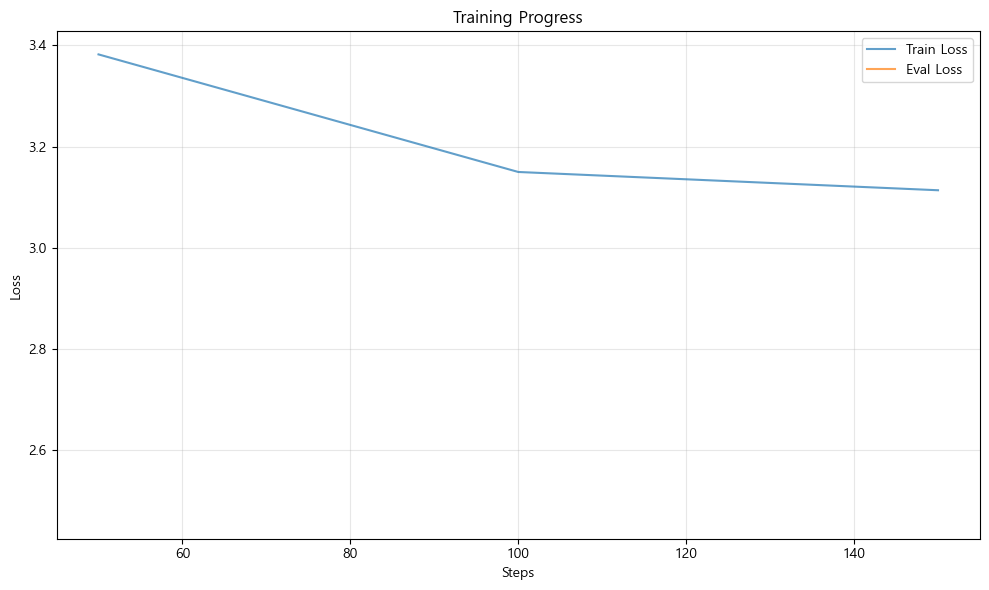

In [ ]:
# ============================================
# Cell 11: 학습 과정 시각화
# ============================================

# 학습 과정 시각화
# 학습 중 기록된 로그를 가져와서 그래프로 표시
log_history = trainer.state.log_history
train_logs = [log for log in log_history if 'loss' in log]  # 학습 loss 로그
eval_logs = [log for log in log_history if 'eval_loss' in log]  # 검증 loss 로그

if train_logs and eval_logs:
    # 그래프 생성
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 학습 및 검증 loss 데이터 추출
    train_steps = [log['step'] for log in train_logs]
    train_losses = [log['loss'] for log in train_logs]
    eval_steps = [log['step'] for log in eval_logs]
    eval_losses = [log['eval_loss'] for log in eval_logs]
    
    # 그래프 그리기
    ax.plot(train_steps, train_losses, label='Train Loss', alpha=0.7)
    ax.plot(eval_steps, eval_losses, label='Eval Loss', alpha=0.7)
    ax.set_xlabel('Steps')
    ax.set_ylabel('Loss')
    ax.set_title('Training Progress')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("학습 로그가 없어 시각화를 생략합니다.")

### 02. Fine-Tuning 한 텍스트 요약 모델 성능 평가

Fine-tuned된 한국어 텍스트 요약 모델(`./final_kobart_summarization`)의 성능을 ROUGE 메트릭으로 평가합니다.

XL-Sum Korean 테스트 데이터셋을 사용하여 정량적 평가와 시각화를 통해 모델의 요약 품질을 종합적으로 분석합니다.

* Fine-tuned 텍스트 요약 모델 및 XL-Sum Korean 테스트 데이터셋 로드
* 요약 생성 및 후처리 함수 정의 (배치 처리 포함)
* 개별 샘플에 대한 정성적 평가 및 ROUGE 점수 계산
* 전체 테스트 세트에 대한 배치 평가 및 종합 성능 측정
* ROUGE 점수 분포 및 압축률 등을 시각화하여 모델 성능 분석

In [19]:
# ============================================
# Cell 1: 환경 설정 및 라이브러리 임포트
# ============================================

import torch
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer  # ROUGE 점수 계산을 위한 라이브러리
import evaluate  # Hugging Face의 평가 메트릭 라이브러리
import re
from datasets import load_dataset
from transformers import (
    PreTrainedTokenizerFast,
    BartForConditionalGeneration
)
from peft import PeftModel  # LoRA 모델 로드용
import warnings
warnings.filterwarnings('ignore')

# Transformers 경고 메시지 레벨 설정
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

print("라이브러리 임포트 완료!")

라이브러리 임포트 완료!


In [20]:
# ============================================
# Cell 2: GPU 설정 및 모델/데이터 로드
# ============================================

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

print("\n" + "="*50)
print("1. 모델 및 데이터 로드")
print("="*50)

# 모델과 토크나이저 경로 설정
model_path = "./final_kobart_summarization"  # Fine-tuned 모델 저장 경로
base_model_name = "gangyeolkim/kobart-korean-summarizer-v2"  # 기본 모델 이름

# 토크나이저 로드
# Fine-tuned 모델의 토크나이저를 우선 시도, 없으면 base 모델의 토크나이저 사용
try:
    tokenizer = PreTrainedTokenizerFast.from_pretrained(model_path)
    print(f"Fine-tuned 모델의 토크나이저를 로드했습니다: {model_path}")
except:
    tokenizer = PreTrainedTokenizerFast.from_pretrained(base_model_name)
    print(f"Base 모델의 토크나이저를 로드했습니다: {base_model_name}")

# 모델 로드
# Fine-tuned 모델이 있으면 사용, 없으면 base 모델 사용
try:
    # Fine-tuned 모델 로드 시도
    model = BartForConditionalGeneration.from_pretrained(
        model_path,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map=None
    )
    print(f"Fine-tuned 모델을 로드했습니다: {model_path}")
except:
    # Base 모델 로드
    print(f"Fine-tuned 모델을 찾을 수 없어 base 모델을 로드합니다: {base_model_name}")
    model = BartForConditionalGeneration.from_pretrained(
        base_model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map=None
    )

# 모델을 지정된 디바이스로 이동하고 평가 모드로 설정
model = model.to(device)
model.eval()  # 평가 모드 (dropout 등 비활성화)

# 데이터셋 로드
dataset = load_dataset("csebuetnlp/xlsum", "korean")
print(f"테스트 데이터: {len(dataset['test'])}개")

# ROUGE 메트릭 로드
# ROUGE (Recall-Oriented Understudy for Gisting Evaluation)는 요약 평가에 널리 사용되는 메트릭
rouge_metric = evaluate.load("rouge")

Device: cuda

1. 모델 및 데이터 로드
Fine-tuned 모델의 토크나이저를 로드했습니다: ./final_kobart_summarization
Fine-tuned 모델을 로드했습니다: ./final_kobart_summarization
테스트 데이터: 550개


In [21]:
# ============================================
# Cell 3: 후처리 및 평가 함수 정의
# ============================================

print("\n" + "="*50)
print("2. 후처리 및 평가 함수 정의")
print("="*50)

def postprocess_summary(summary):
    """
    생성된 요약문을 후처리하는 함수
    - 공백 정리
    - 문장 부호 정리
    - 중복 문장 제거
    - 길이 제한
    """
    # 연속된 공백을 하나의 공백으로 변환
    summary = ' '.join(summary.split())
    
    # 문장 부호 앞의 불필요한 공백 제거
    summary = re.sub(r'\s+([.!?])', r'\1', summary)
    
    # 문장 단위로 분리하여 중복 제거
    sentences = summary.split('.')
    unique_sentences = []
    for sent in sentences:
        # 빈 문장이 아니고 이미 추가되지 않은 문장만 추가
        if sent.strip() and sent.strip() not in unique_sentences:
            unique_sentences.append(sent.strip())
    
    # 문장들을 다시 합치기
    summary = '. '.join(unique_sentences)
    # 마지막에 마침표가 없으면 추가
    if not summary.endswith('.'):
        summary += '.'
    
    # 요약문이 너무 길면 잘라내기
    if len(summary) > 200:  # 200자 제한
        summary = summary[:197] + '...'
    
    return summary

def generate_summary(text, max_length=128, num_beams=4):
    """
    텍스트를 입력받아 요약을 생성하는 함수
    
    Parameters:
    - text: 요약할 원문 텍스트
    - max_length: 생성할 요약문의 최대 길이
    - num_beams: 빔 서치에서 사용할 빔의 개수 (높을수록 품질 향상, 속도 저하)
    
    Returns:
    - 생성된 요약문
    """
    # 입력 텍스트를 토큰화
    inputs = tokenizer(
        text,
        max_length=1024,  # 입력 최대 길이
        truncation=True,  # 긴 텍스트는 자르기
        return_tensors="pt"  # PyTorch 텐서로 반환
    )
    
    # BART는 token_type_ids를 사용하지 않으므로 제거
    if "token_type_ids" in inputs:
        del inputs["token_type_ids"]
    
    # 입력을 디바이스로 이동
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 추론 모드에서 요약 생성
    with torch.no_grad():  # 그래디언트 계산 비활성화 (메모리 절약)
        summary_ids = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            no_repeat_ngram_size=3,  # 3-gram 반복 방지
            temperature=0.9,  # 생성 다양성 조절 (낮을수록 확정적)
            do_sample=False  # 샘플링 사용 안함 (빔 서치만 사용)
        )
    
    # 생성된 토큰을 텍스트로 디코딩
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    
    # 후처리 적용
    summary = postprocess_summary(summary)
    
    return summary

def batch_generate_summaries(texts, batch_size=8):
    """
    여러 텍스트를 배치 단위로 처리하여 요약을 생성하는 함수
    메모리 효율성과 속도를 위해 배치 처리 사용
    
    Parameters:
    - texts: 요약할 텍스트들의 리스트
    - batch_size: 한 번에 처리할 텍스트 개수
    
    Returns:
    - 생성된 요약문들의 리스트
    """
    summaries = []
    
    # 배치 단위로 처리
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating summaries"):
        batch_texts = texts[i:i+batch_size]
        
        # 배치 토큰화
        inputs = tokenizer(
            batch_texts,
            max_length=1024,
            truncation=True,
            padding=True,  # 배치 내에서 가장 긴 시퀀스에 맞춰 패딩
            return_tensors="pt"
        )
        
        # token_type_ids 제거
        if "token_type_ids" in inputs:
            del inputs["token_type_ids"]
            
        # 디바이스로 이동
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # 배치 추론
        with torch.no_grad():
            summary_ids = model.generate(
                **inputs,
                max_length=128,
                num_beams=4,
                no_repeat_ngram_size=3
            )
        
        # 배치 디코딩
        batch_summaries = tokenizer.batch_decode(summary_ids, skip_special_tokens=True)
        # 각 요약문에 후처리 적용
        batch_summaries = [postprocess_summary(summary) for summary in batch_summaries]
        summaries.extend(batch_summaries)
        
        # 주기적으로 GPU 메모리 정리
        if i % (batch_size * 5) == 0:
            torch.cuda.empty_cache()
    
    return summaries

print("평가 함수 정의 완료!")


2. 후처리 및 평가 함수 정의
평가 함수 정의 완료!


In [22]:
# ============================================
# Cell 4: 개별 샘플 평가
# ============================================

print("\n" + "="*50)
print("3. 개별 샘플 평가")
print("="*50)

# 5개 샘플에 대한 상세 평가
# 실제 데이터를 통해 모델의 성능을 정성적으로 확인
test_samples = dataset['test'].select(range(5))

for i, sample in enumerate(test_samples):
    print(f"\n--- 샘플 {i+1} ---")
    # 원문의 앞부분만 출력 (전체가 너무 길 수 있으므로)
    print(f"원문 (앞 200자): {sample['text'][:200]}...")
    print(f"\n실제 요약: {sample['summary']}")
    
    # 모델을 사용해 요약 생성
    generated_summary = generate_summary(sample['text'])
    print(f"\n생성된 요약: {generated_summary}")
    
    # ROUGE 점수 계산
    # ROUGE-1: 단일 단어(unigram) 기준 일치도
    # ROUGE-2: 연속된 두 단어(bigram) 기준 일치도
    # ROUGE-L: 최장 공통 부분 수열 기준 일치도
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    scores = scorer.score(sample['summary'], generated_summary)
    
    print(f"\nROUGE 점수:")
    print(f"  ROUGE-1: {scores['rouge1'].fmeasure:.4f}")
    print(f"  ROUGE-2: {scores['rouge2'].fmeasure:.4f}")
    print(f"  ROUGE-L: {scores['rougeL'].fmeasure:.4f}")


3. 개별 샘플 평가

--- 샘플 1 ---
원문 (앞 200자): '센과 치히로'가 개봉 18년 만에 중국에서 돌풍을 일으키고 있다 중국의 최대 영화예매 앱인 '마오얀'에 따르면 '센과 치히로'는 약 2770만 달러(약 320억 원)의 수익을 올렸다. 같은 날 개봉한 디즈니 신작 '토이스토리 4'의 두 배가 넘는 수익이다. '센과 치히로'는 2001년에 개봉했지만, 중국에서는 이번에 첫 개봉했다. 하지만 중국에서는 이미 ...

실제 요약: '센과 치히로의 행방불명(Spirited Away)'이 지난 주말 중국에서 개봉한 후 화제다.

생성된 요약: '센과 치히로'가 개봉 18년 만에 중국에서 돌풍을 일으키고 있다. 중국에서는 이미 이 영화를 DVD 등 암암리에 접한 사람이 많으며, 팬층이 두껍게 형성되어 있다. 중국에선 30년이 지난 작년 12월에야 개봉했다. 중국과 일본 간의 긴장 때문에 특히 일본 영화는 스크린에서 볼 수 없었다.

ROUGE 점수:
  ROUGE-1: 0.0000
  ROUGE-2: 0.0000
  ROUGE-L: 0.0000

--- 샘플 2 ---
원문 (앞 200자): 이번 해킹은 국가 핵심 기반시설에 대한 공격 중 역사상 최악의 사례로 여겨진다. 콜로니얼 파이프라인은 미국 동부로 가는 연료의 절반을 책임지고 있는 만큼 가동 중단이 장기화할 경우 유가 상승으로 이어질 것이라는 우려도 나오고 있다. 송유관 해킹 석유 산업 하면 파이프와 펌프, 새까만 원유 등 다소 투박한 이미지가 떠오른다. 하지만 사실 콜로니얼 파이프라인 ...

실제 요약: 현지시간 지난 7일 미국 송유관 업체 '콜로니얼 파이프라인'을 마비시킨 사이버 공격에 대한 조사가 한창이다.

생성된 요약: 미국 동부 석유회사 콜로니얼 파이프라인(Colonicope Pione)의 송유관이 해킹당했다는 소식이 전해졌다. 이 회사는 미국 동부로 가는 연료의 절반을 책임지고 있는 만큼 가동 중단이 장기화할 경우 유가 상승으로 이어질 것이라는 우려가 나오고 있다.

ROUGE 

In [23]:
# ============================================
# Cell 5: 전체 테스트 세트 평가
# ============================================

print("\n" + "="*50)
print("4. 전체 테스트 세트 평가")
print("="*50)

# 전체 평가를 위한 샘플 선택 (100개로 제한하여 시간 절약)
eval_samples = dataset['test'].select(range(100))
eval_texts = [sample['text'] for sample in eval_samples]
eval_summaries = [sample['summary'] for sample in eval_samples]

print(f"\n{len(eval_texts)}개 샘플에 대한 평가를 시작합니다...")
# 배치 단위로 요약 생성
generated_summaries = batch_generate_summaries(eval_texts)

# 전체 ROUGE 점수 계산
# Hugging Face의 evaluate 라이브러리를 사용하여 집계
results = rouge_metric.compute(
    predictions=generated_summaries,
    references=eval_summaries,
    use_stemmer=False  # 한국어는 stemming 사용 안함
)

print("\n전체 성능 평가 결과:")
print(f"ROUGE-1: {results['rouge1'] * 100:.2f}%")
print(f"ROUGE-2: {results['rouge2'] * 100:.2f}%")
print(f"ROUGE-L: {results['rougeL'] * 100:.2f}%")

# 개별 점수 계산 (분포 분석용)
# 각 샘플의 ROUGE 점수를 개별적으로 계산하여 분포 확인
rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
for pred, ref in zip(generated_summaries, eval_summaries):
    scores = scorer.score(ref, pred)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

print("개별 점수 계산 완료!")


4. 전체 테스트 세트 평가

100개 샘플에 대한 평가를 시작합니다...


Generating summaries:   0%|          | 0/13 [00:00<?, ?it/s]


전체 성능 평가 결과:
ROUGE-1: 12.05%
ROUGE-2: 1.87%
ROUGE-L: 12.04%
개별 점수 계산 완료!



5. 결과 시각화


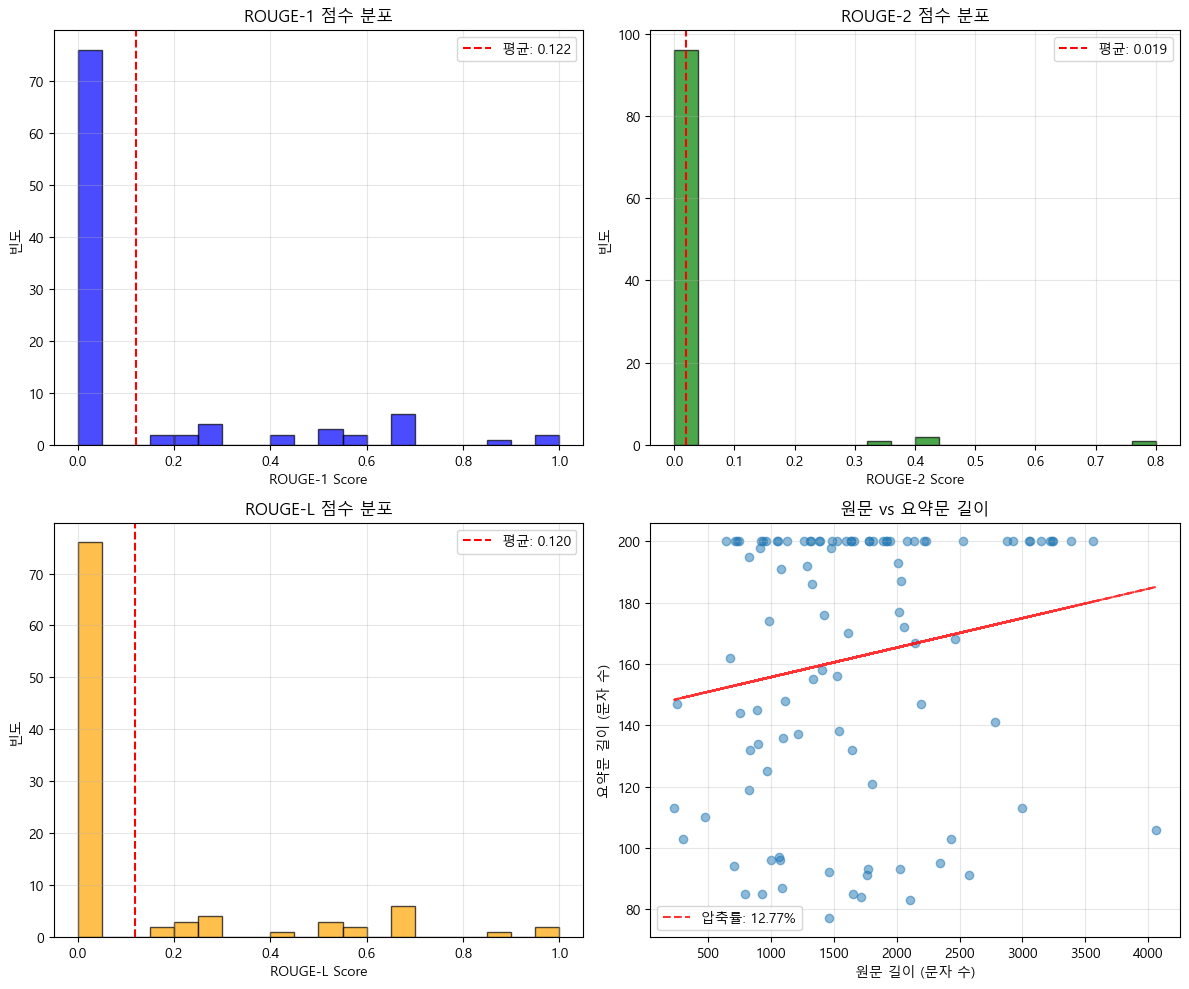


요약 통계:
평균 원문 길이: 1645 문자
평균 요약문 길이: 162 문자
평균 압축률: 12.77%


In [24]:
# ============================================
# Cell 6: 결과 시각화
# ============================================

print("\n" + "="*50)
print("5. 결과 시각화")
print("="*50)

# 4개의 서브플롯으로 구성된 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ROUGE-1 점수 분포 히스토그램
axes[0, 0].hist(rouge1_scores, bins=20, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(np.mean(rouge1_scores), color='red', linestyle='--', 
                    label=f'평균: {np.mean(rouge1_scores):.3f}')
axes[0, 0].set_xlabel('ROUGE-1 Score')
axes[0, 0].set_ylabel('빈도')
axes[0, 0].set_title('ROUGE-1 점수 분포')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ROUGE-2 점수 분포 히스토그램
axes[0, 1].hist(rouge2_scores, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(np.mean(rouge2_scores), color='red', linestyle='--', 
                    label=f'평균: {np.mean(rouge2_scores):.3f}')
axes[0, 1].set_xlabel('ROUGE-2 Score')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].set_title('ROUGE-2 점수 분포')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ROUGE-L 점수 분포 히스토그램
axes[1, 0].hist(rougeL_scores, bins=20, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].axvline(np.mean(rougeL_scores), color='red', linestyle='--', 
                    label=f'평균: {np.mean(rougeL_scores):.3f}')
axes[1, 0].set_xlabel('ROUGE-L Score')
axes[1, 0].set_ylabel('빈도')
axes[1, 0].set_title('ROUGE-L 점수 분포')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 원문 길이 vs 요약문 길이 산점도
original_lengths = [len(text) for text in eval_texts]
summary_lengths = [len(summary) for summary in generated_summaries]
compression_ratios = [s_len / o_len for o_len, s_len in zip(original_lengths, summary_lengths)]

axes[1, 1].scatter(original_lengths, summary_lengths, alpha=0.5)
axes[1, 1].set_xlabel('원문 길이 (문자 수)')
axes[1, 1].set_ylabel('요약문 길이 (문자 수)')
axes[1, 1].set_title('원문 vs 요약문 길이')
axes[1, 1].grid(True, alpha=0.3)

# 선형 회귀를 통한 추세선 추가
z = np.polyfit(original_lengths, summary_lengths, 1)
p = np.poly1d(z)
axes[1, 1].plot(original_lengths, p(original_lengths), "r--", alpha=0.8, 
                label=f'압축률: {np.mean(compression_ratios):.2%}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 요약 통계 출력
print(f"\n요약 통계:")
print(f"평균 원문 길이: {np.mean(original_lengths):.0f} 문자")
print(f"평균 요약문 길이: {np.mean(summary_lengths):.0f} 문자")
print(f"평균 압축률: {np.mean(compression_ratios):.2%}")

In [25]:
# ============================================
# Cell 7: 성능 분석 요약
# ============================================

print("\n" + "="*50)
print("6. 성능 분석 요약")
print("="*50)

# 최종 성능 요약 및 표준편차 포함
print(f"\n최종 성능 요약:")
print(f"- ROUGE-1: {results['rouge1'] * 100:.2f}% (±{np.std(rouge1_scores) * 100:.2f})")
print(f"- ROUGE-2: {results['rouge2'] * 100:.2f}% (±{np.std(rouge2_scores) * 100:.2f})")
print(f"- ROUGE-L: {results['rougeL'] * 100:.2f}% (±{np.std(rougeL_scores) * 100:.2f})")

# 성능 등급 판정
# 세 가지 ROUGE 점수의 평균을 기준으로 등급 부여
avg_rouge = (results['rouge1'] + results['rouge2'] + results['rougeL']) / 3 * 100
if avg_rouge >= 40:
    grade = "우수"
elif avg_rouge >= 30:
    grade = "양호"
elif avg_rouge >= 20:
    grade = "보통"
else:
    grade = "개선 필요"

print(f"\n종합 평가: {grade} (평균 ROUGE: {avg_rouge:.2f}%)")

print("\n모델 평가 완료!")
print("\n사용 방법:")
print("summary = generate_summary('요약할 텍스트를 입력하세요')")


6. 성능 분석 요약

최종 성능 요약:
- ROUGE-1: 12.05% (±24.69)
- ROUGE-2: 1.87% (±10.17)
- ROUGE-L: 12.04% (±24.55)

종합 평가: 개선 필요 (평균 ROUGE: 8.65%)

모델 평가 완료!

사용 방법:
summary = generate_summary('요약할 텍스트를 입력하세요')
